# Tutorial 2b: Spatial Visualization of Compositionally Diverse Samples

**Systems Biology — Spatial Proteomics Module**

## Purpose

This notebook visualises the **15 most compositionally diverse IMC images** identified by `analyze_sample_variability.py` — the top 3 per cancer indication (BREAS, GI, GU, HN, THOR), ranked by:

$$\text{composite score} = \underbrace{H(p)}_\text{Shannon entropy} \times \underbrace{(1 - p_\text{tumor})}_\text{immune infiltration}$$

These samples were chosen **specifically to avoid pure-tumor slides** and to showcase rich immune microenvironments suitable for spatial interaction analysis.

## What you will see
1. **Per-image scatter plots** — each cell plotted at its physical X/Y coordinates, coloured by cell type
2. **Per-indication panels** — all 3 ranked images side-by-side for each cancer type
3. **Composition bar charts** — cell-type proportions alongside each spatial map
4. **Cross-indication overview** — the #1 pick from each cancer type on one page

---

In [9]:
import json
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
sns.set_style('white')

DATA_PATH    = 'data/train_adata.h5ad'
SAMPLES_PATH = 'supplementary_files/diverse_samples_per_indication.json'

---
## Part 1: Load Data and Curated Sample List

In [ ]:
print('Loading AnnData...')
adata = ad.read_h5ad(DATA_PATH)
# 'exprs' layer is already arcsinh(x/5)-transformed (applied at data export).
# Alias it to 'exprs_arcsinh' for clarity; do NOT re-apply arcsinh.
if 'exprs_arcsinh' not in adata.layers:
    adata.layers['exprs_arcsinh'] = adata.layers['exprs']  # already arcsinh(x/5)

print(f'  {adata.n_obs:,} cells  |  {adata.obs["image"].nunique()} images')

# Load curated sample list
with open(SAMPLES_PATH) as f:
    diverse_samples = json.load(f)

# Flat ordered list: [(indication, rank, entry_dict), ...]
flat_samples = [
    (ind, entry['rank'], entry)
    for ind, entries in diverse_samples.items()
    for entry in entries
]

print(f'\nCurated samples: {len(flat_samples)} images across {len(diverse_samples)} indications')
print(f'{"Ind":<6} {"Rank":<5} {"Cells":>6} {"Tumor":>7} {"Entropy":>8} {"Composite":>10}  Sample')
print('-' * 90)
for ind, rank, e in flat_samples:
    short = ('...' + e['image'][-37:]) if len(e['image']) > 40 else e['image']
    print(f'{ind:<6} #{rank:<4} {e["n_cells"]:>6} {e["tumor_prop"]:>7.1%} '
          f'{e["shannon_entropy"]:>8.3f} {e["composite_score"]:>10.3f}  {short}')

---
## Part 2: Colour Palette for Cell Types

A consistent palette is critical — the same colour must mean the same cell type across all plots in this notebook.

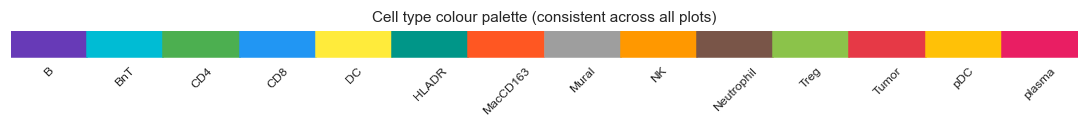

In [11]:
# ── Fixed cell-type colour palette (tab20 extended) ───────────────────────────
CELL_TYPES = sorted(adata.obs['celltypes'].unique().tolist())

# Assign biologically motivated colours where possible
MANUAL_COLORS = {
    'Tumor'    : '#E63946',  # red
    'CD8'      : '#2196F3',  # blue
    'CD4'      : '#4CAF50',  # green
    'Treg'     : '#8BC34A',  # light green
    'BnT'      : '#00BCD4',  # cyan
    'B'        : '#673AB7',  # purple
    'NK'       : '#FF9800',  # orange
    'MacCD163' : '#FF5722',  # deep orange
    'Mural'    : '#9E9E9E',  # grey
    'DC'       : '#FFEB3B',  # yellow
    'pDC'      : '#FFC107',  # amber
    'HLADR'    : '#009688',  # teal
    'Neutrophil': '#795548', # brown
    'plasma'   : '#E91E63',  # pink
}
# Fill any missing cell types with tab20
extra_colors = sns.color_palette('tab20', 20)
extra_idx = 0
for ct in CELL_TYPES:
    if ct not in MANUAL_COLORS:
        MANUAL_COLORS[ct] = extra_colors[extra_idx]
        extra_idx += 1

CT_PALETTE = {ct: MANUAL_COLORS[ct] for ct in CELL_TYPES}

# Show the palette
fig, ax = plt.subplots(figsize=(10, 1.2))
for i, ct in enumerate(CELL_TYPES):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=CT_PALETTE[ct]))
    ax.text(i + 0.5, -0.35, ct, ha='center', va='top', fontsize=8, rotation=45)
ax.set_xlim(0, len(CELL_TYPES))
ax.set_ylim(-0.5, 1)
ax.axis('off')
ax.set_title('Cell type colour palette (consistent across all plots)', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 3: Helper Function — Single-Image Spatial Map

We define one reusable function that plots the spatial scatter for a single image.

In [12]:
def plot_spatial_image(adata_img, ax, title='', show_legend=True, point_size=6):
    """
    Scatter plot of cells at their physical (Pos_X, Pos_Y) positions,
    coloured by cell type using CT_PALETTE.

    Parameters
    ----------
    adata_img : AnnData subset for a single image
    ax        : matplotlib Axes to draw into
    title     : plot title string
    show_legend : whether to add a legend
    point_size  : scatter dot size
    """
    obs = adata_img.obs
    # Plot each cell type as a separate scatter call (preserves zorder control)
    cell_types_present = obs['celltypes'].value_counts().index.tolist()
    for ct in cell_types_present:
        mask = obs['celltypes'] == ct
        ax.scatter(
            obs.loc[mask, 'Pos_X'],
            obs.loc[mask, 'Pos_Y'],
            c=CT_PALETTE.get(ct, '#cccccc'),
            s=point_size,
            alpha=0.75,
            linewidths=0,
            label=ct,
            rasterized=True,
        )
    ax.set_aspect('equal')
    ax.invert_yaxis()          # IMC convention: origin top-left
    ax.set_xlabel('X (µm)', fontsize=8)
    ax.set_ylabel('Y (µm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_title(title, fontsize=8, pad=4)
    if show_legend:
        handles = [
            mpatches.Patch(color=CT_PALETTE[ct], label=ct)
            for ct in cell_types_present
        ]
        ax.legend(
            handles=handles, fontsize=7, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), framealpha=0.7,
            markerscale=1.5, handlelength=1
        )


def plot_composition_bar(entry, ax):
    """
    Horizontal bar chart of cell-type proportions for one image.
    Uses proportions stored in the JSON entry's top_celltypes (top 5) plus
    recomputes full proportions from adata for accuracy.
    """
    img = entry['image']
    obs_img = adata.obs[adata.obs['image'] == img]
    ct_counts = obs_img['celltypes'].value_counts()
    ct_props  = ct_counts / ct_counts.sum()
    ct_props  = ct_props.sort_values(ascending=True)

    colors = [CT_PALETTE.get(ct, '#cccccc') for ct in ct_props.index]
    ax.barh(ct_props.index, ct_props.values, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Proportion', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_xlim(0, 1)
    for ct, val in ct_props.items():
        if val > 0.03:
            ax.text(val + 0.01, ct, f'{val:.0%}', va='center', fontsize=6)
    ax.set_title('Composition', fontsize=8)


print('Helper functions defined: plot_spatial_image(), plot_composition_bar()')

Helper functions defined: plot_spatial_image(), plot_composition_bar()


---
## Part 4: Per-Indication Panels (Top 3 Diverse Samples Each)

Each row = one cancer indication. Each column = one ranked sample.  
Left panel: spatial map coloured by cell type. Right panel: composition bar chart.

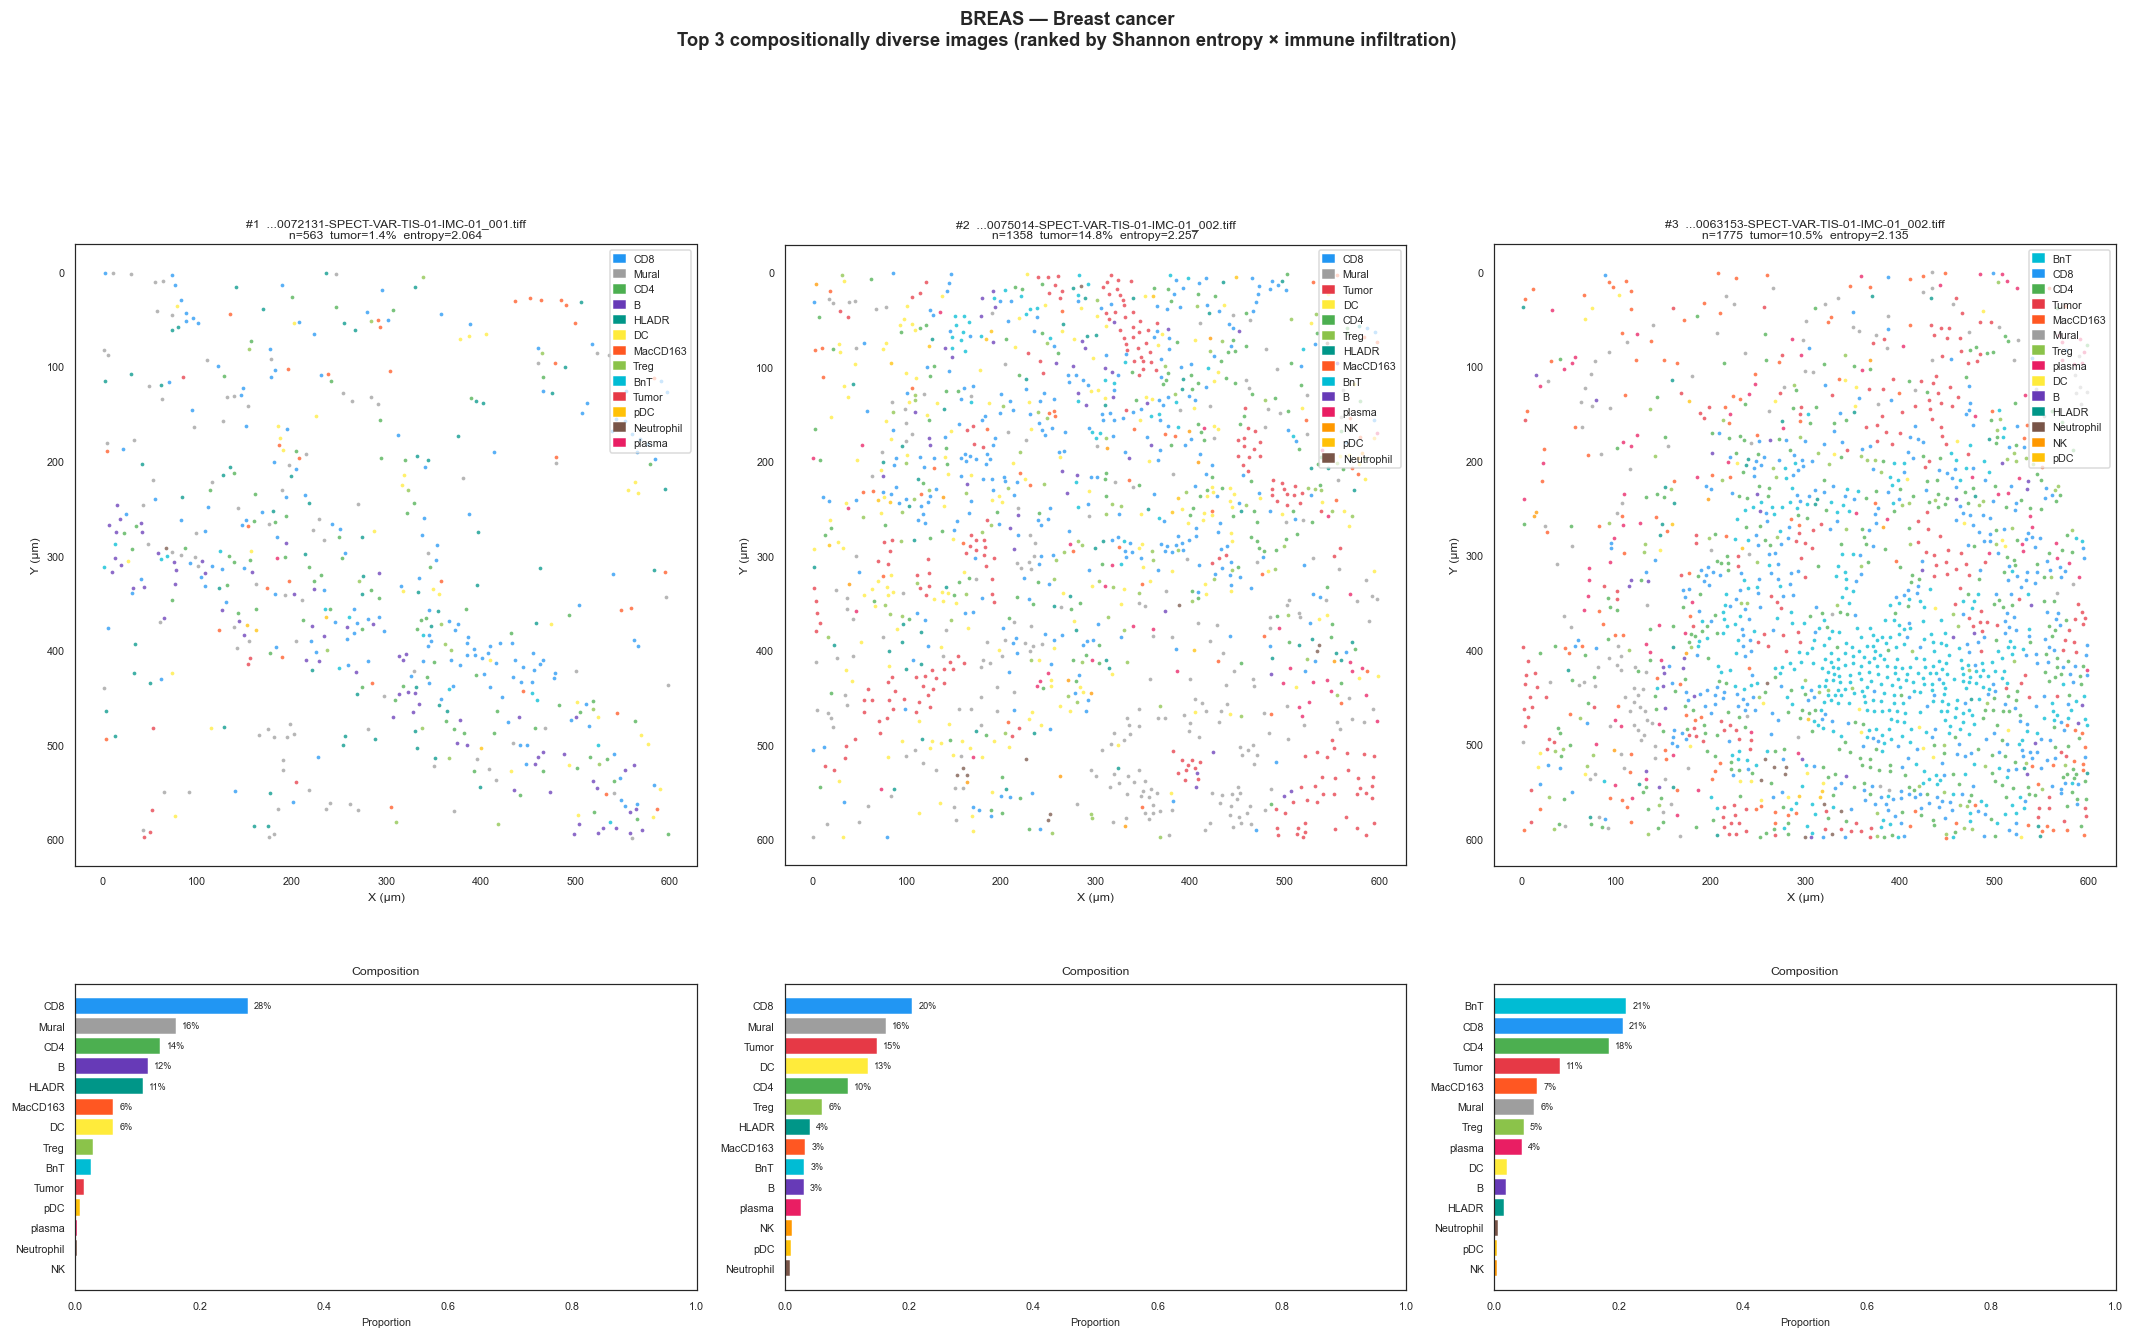

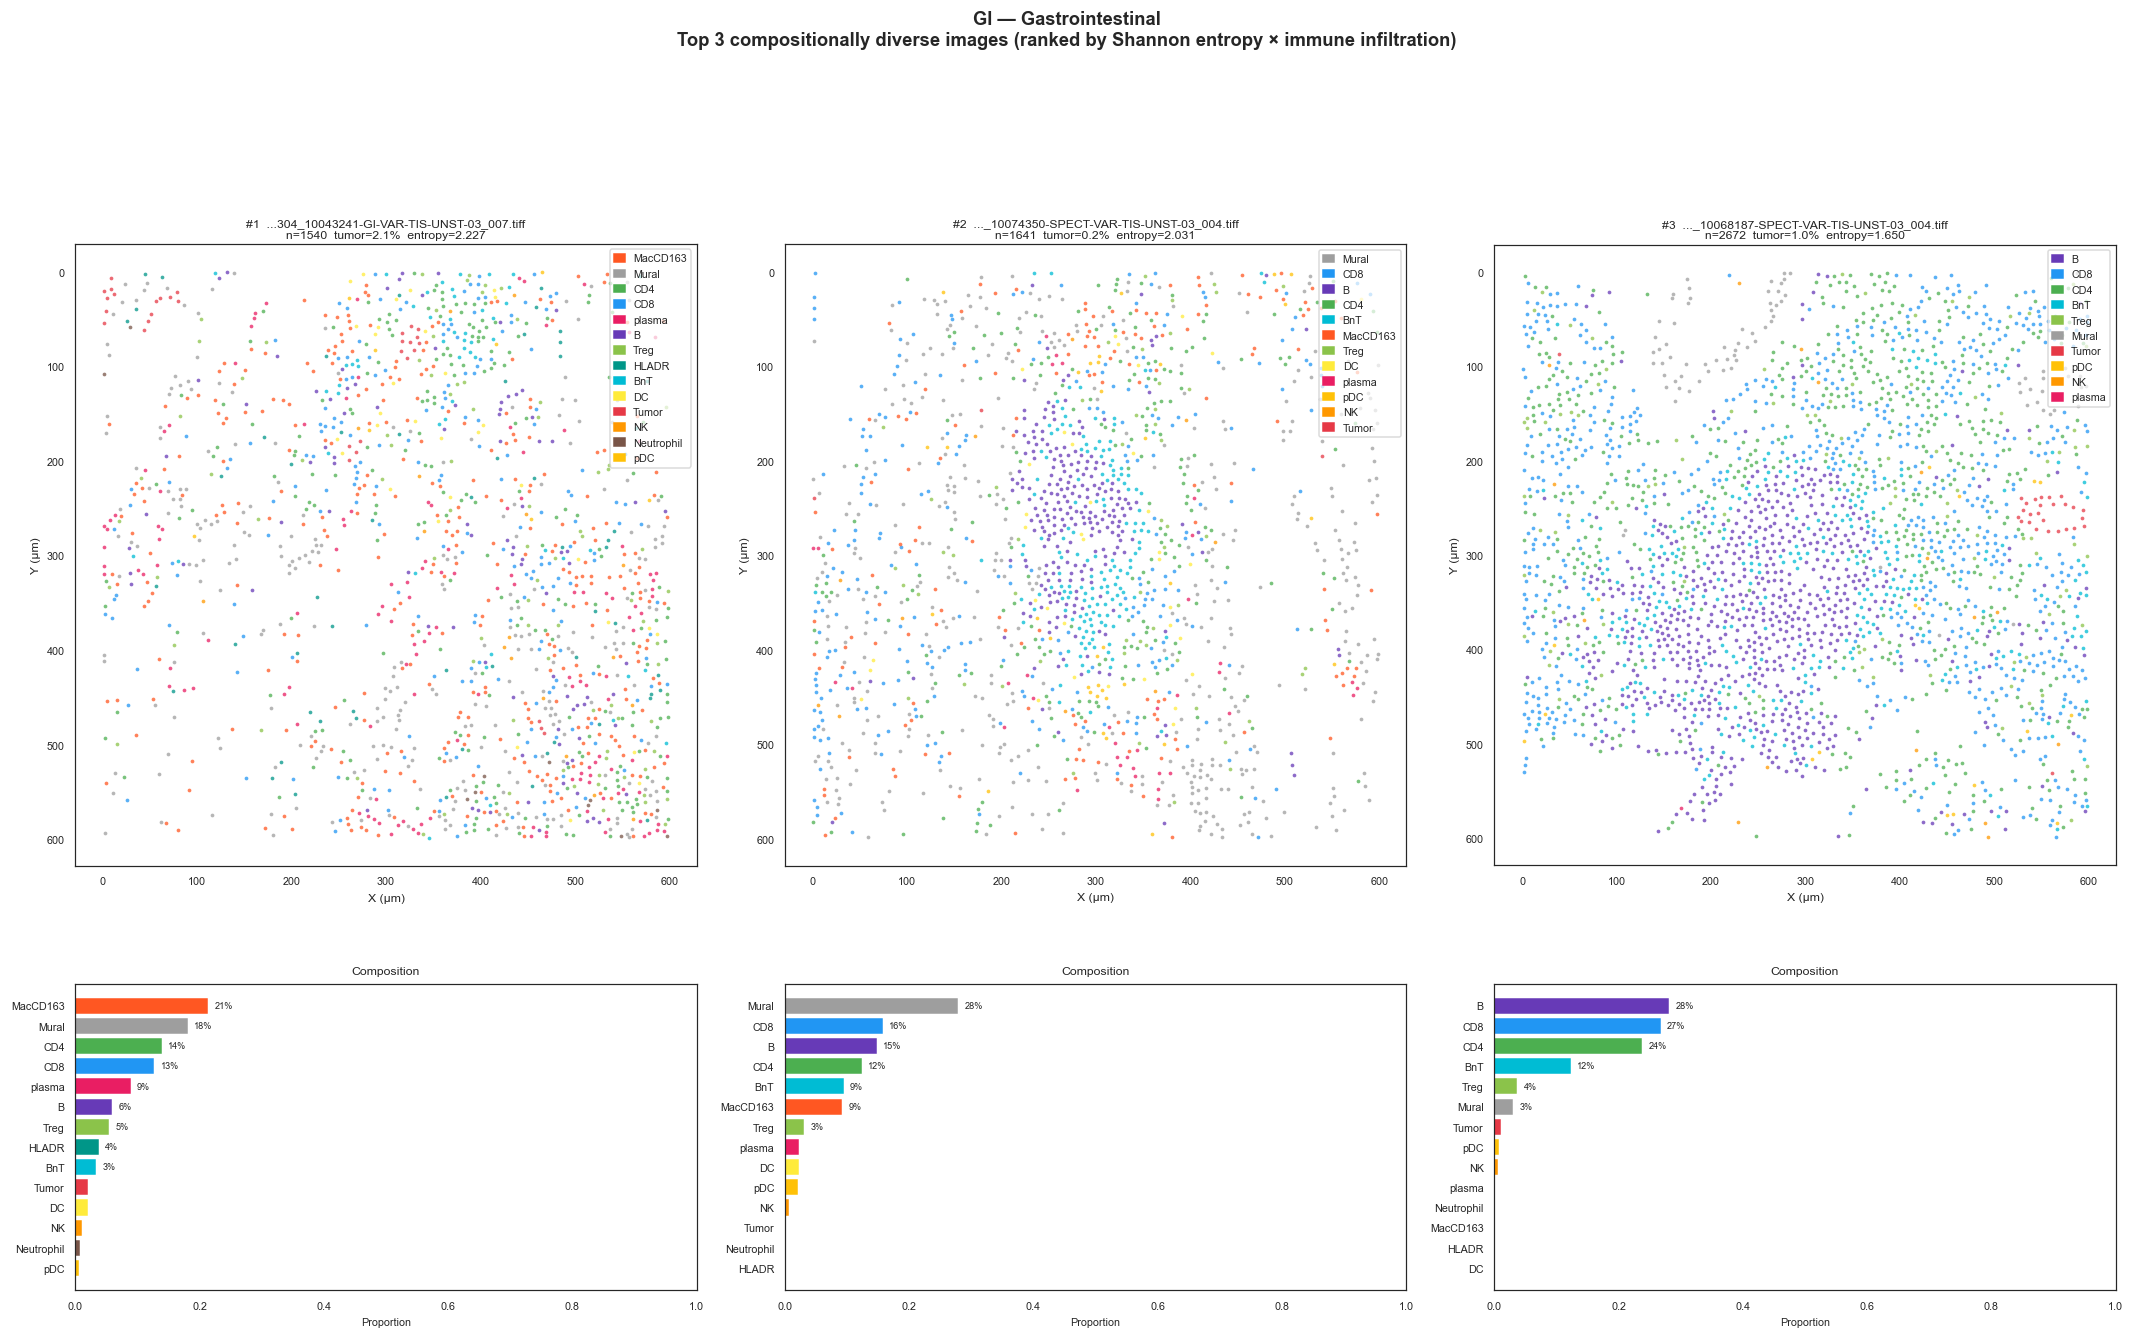

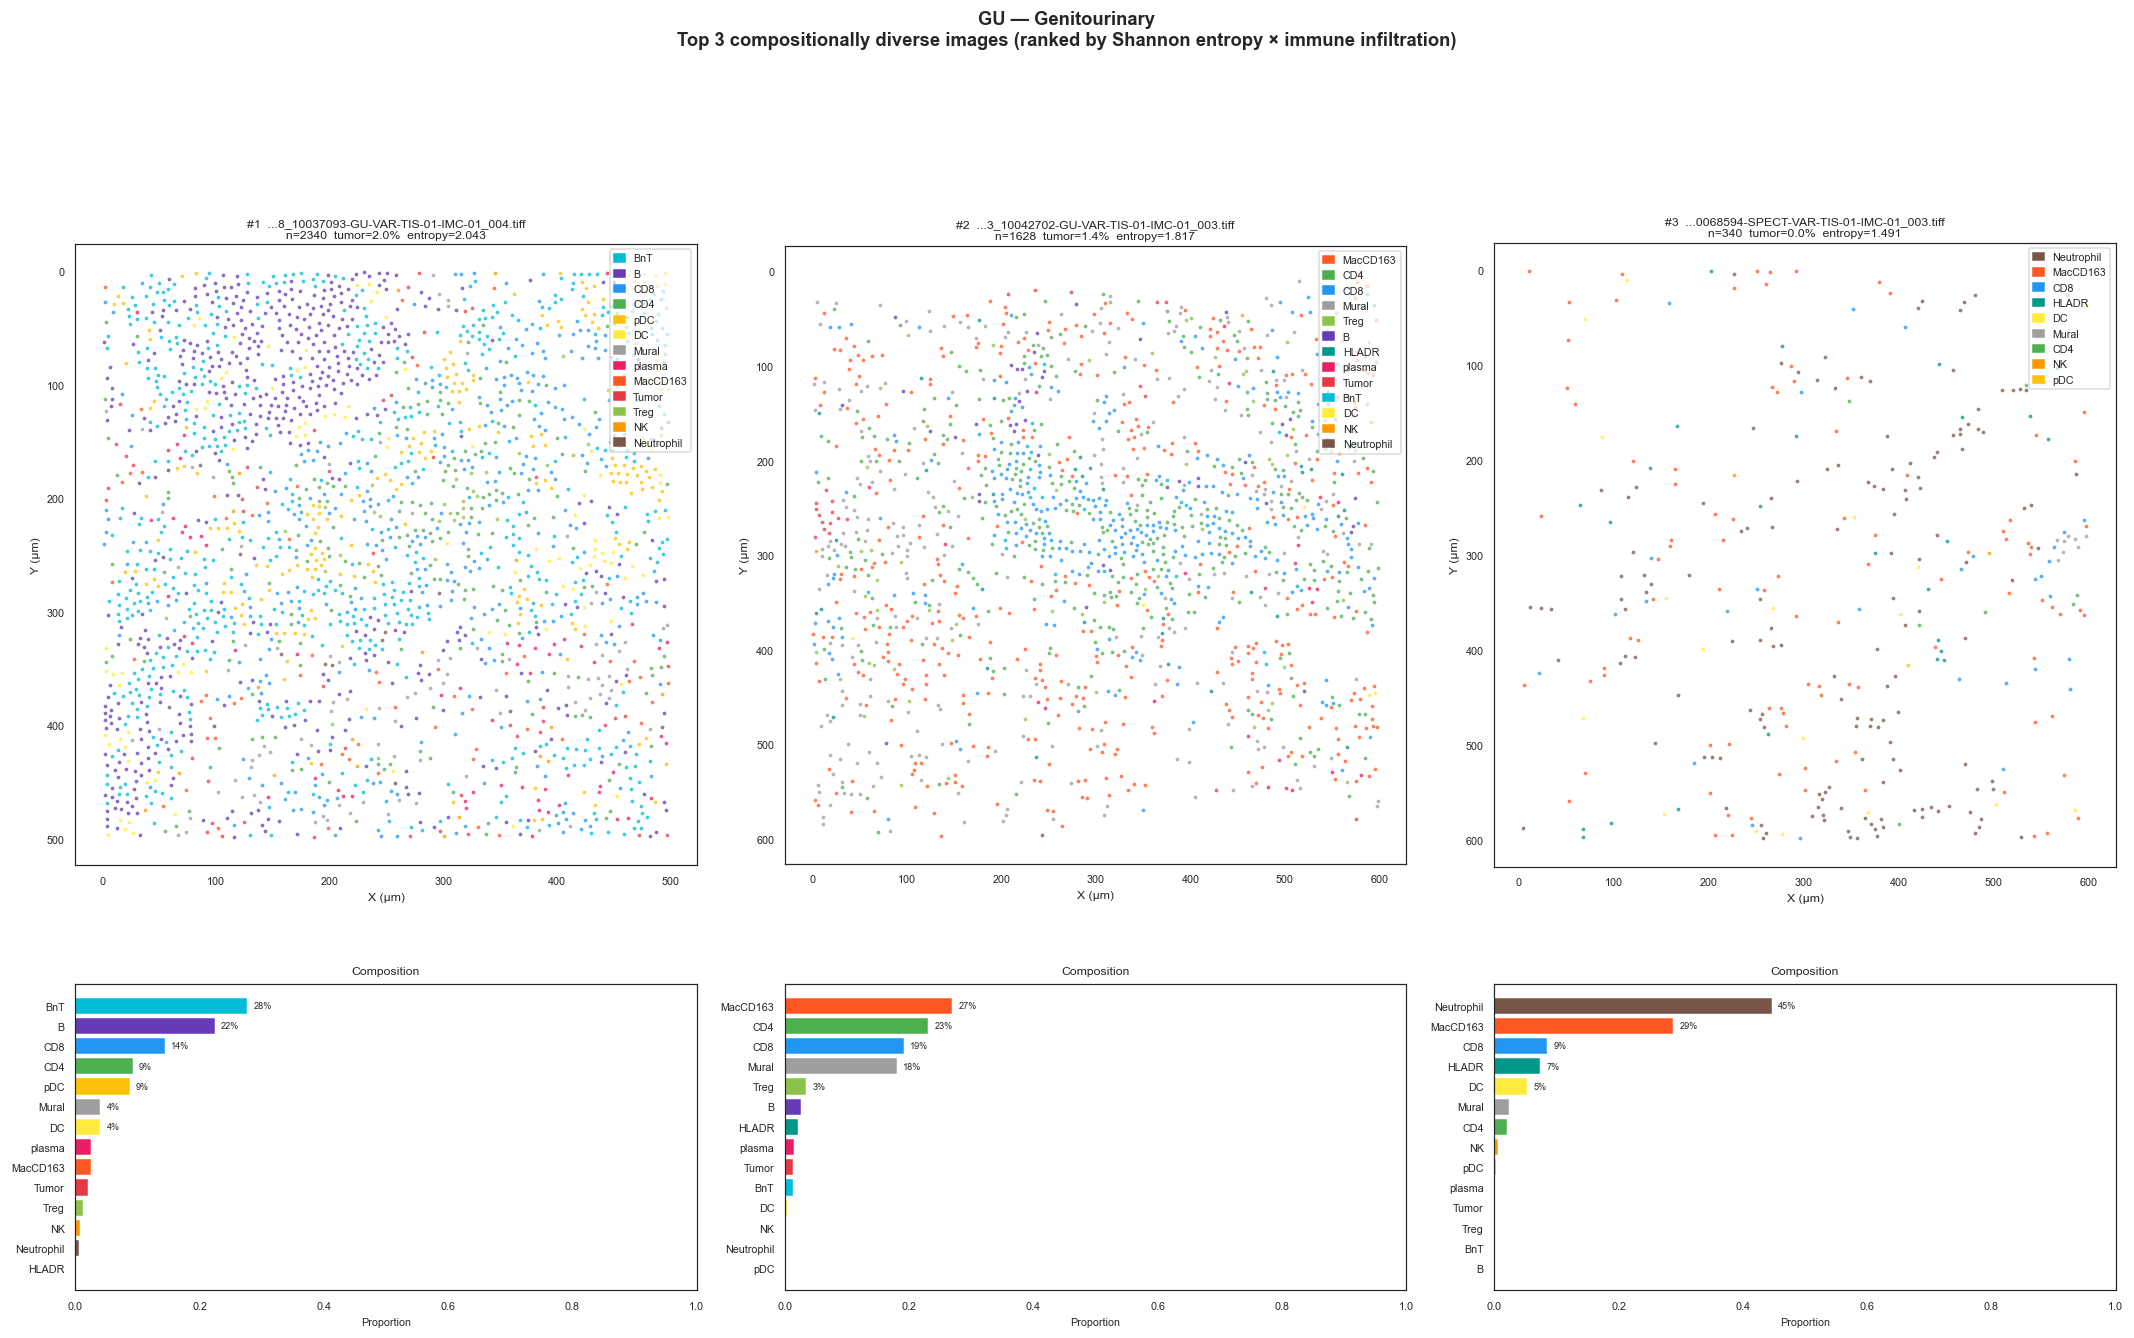

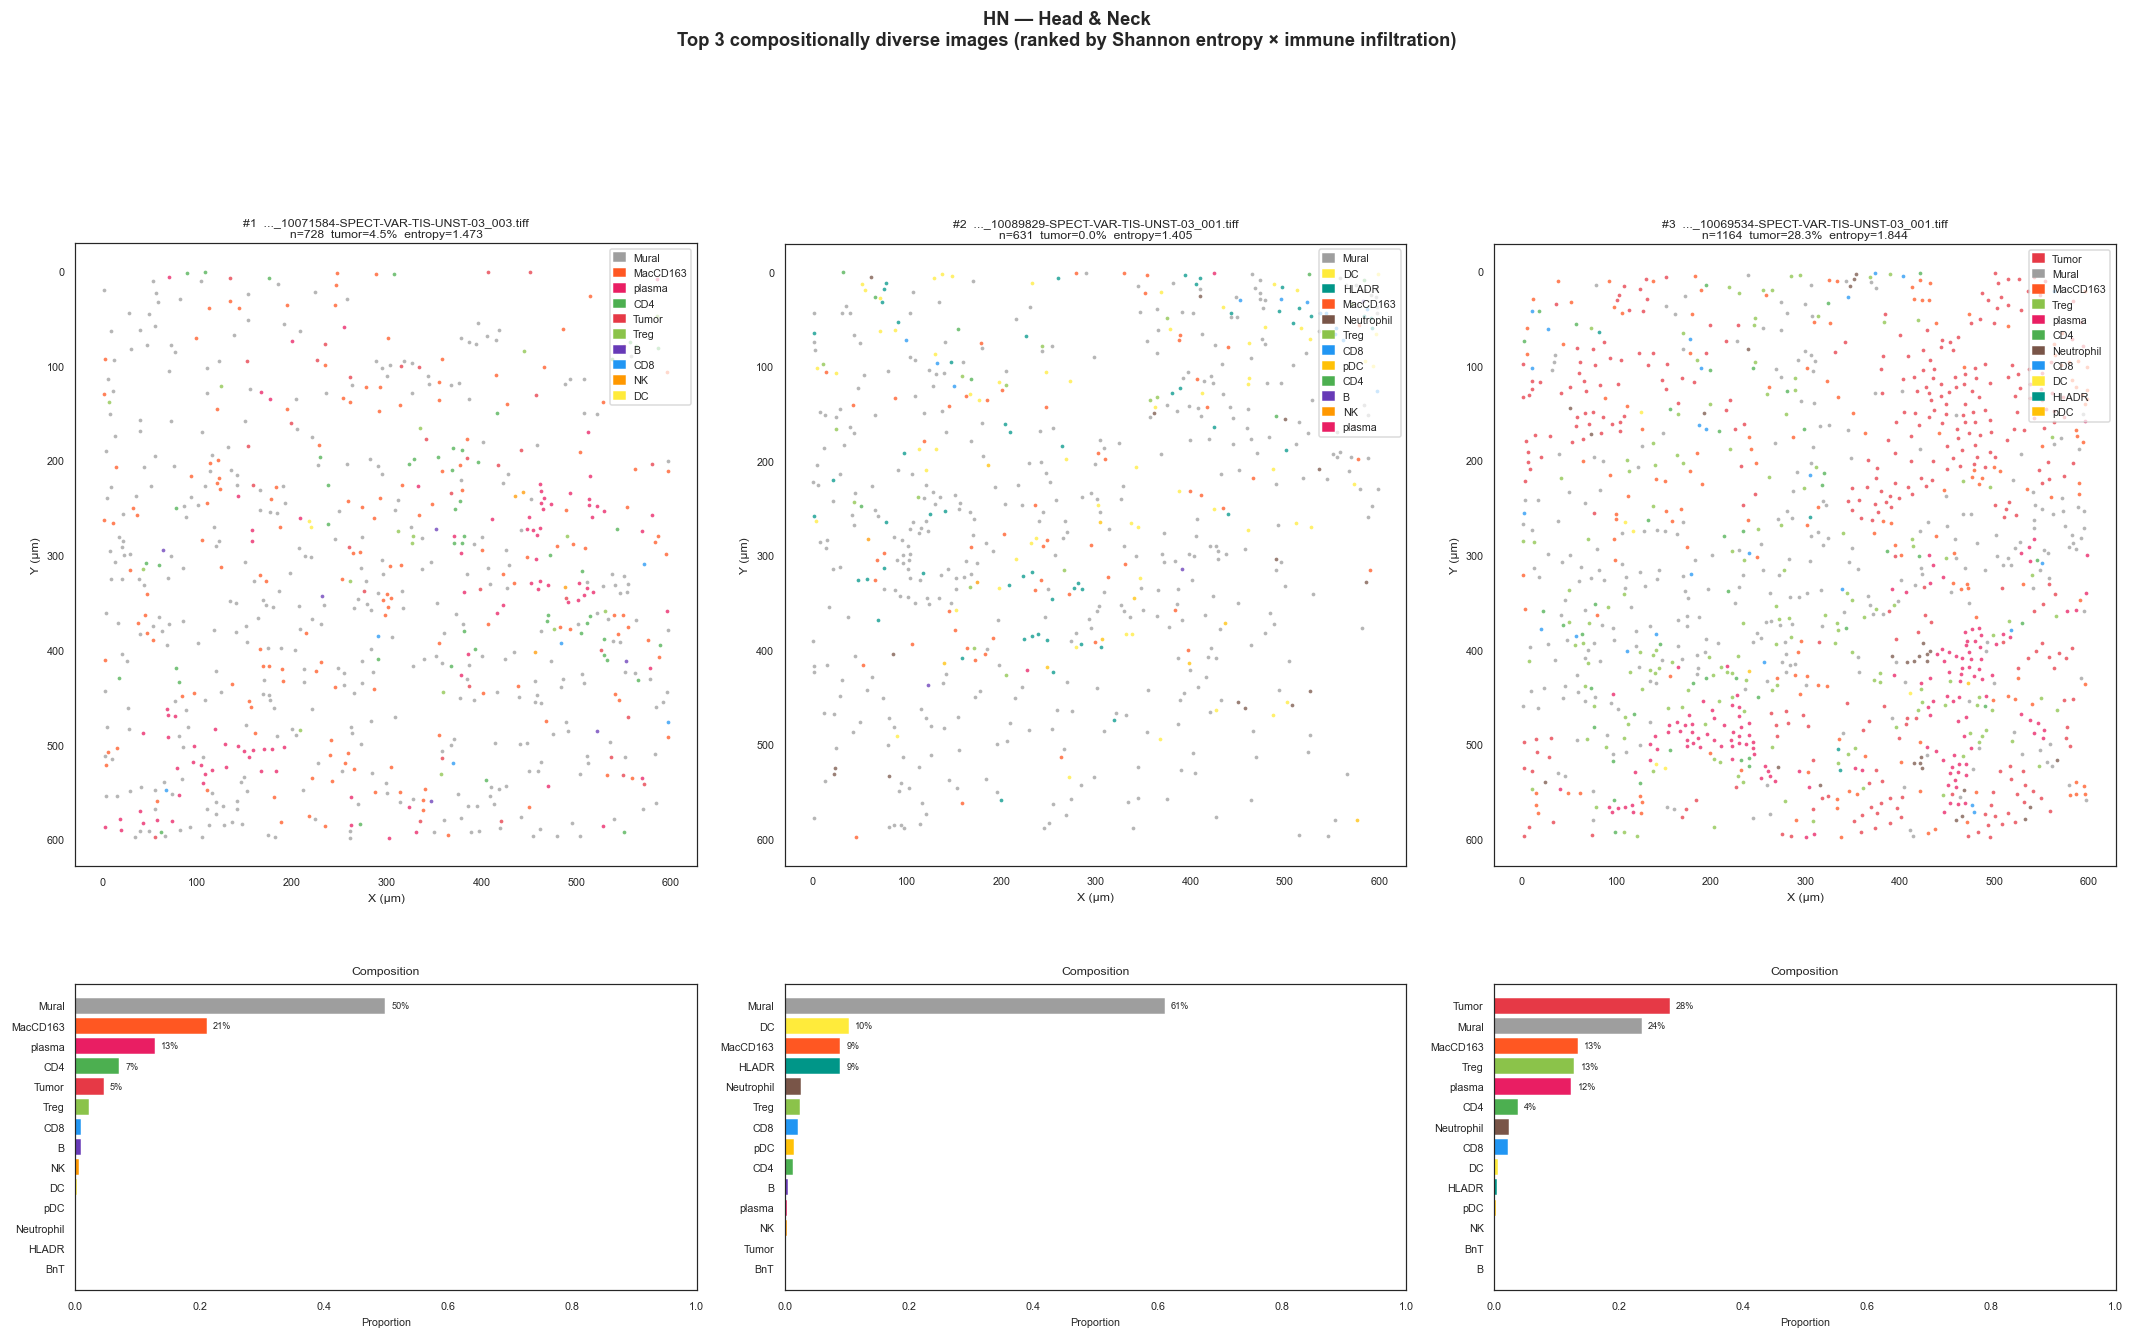

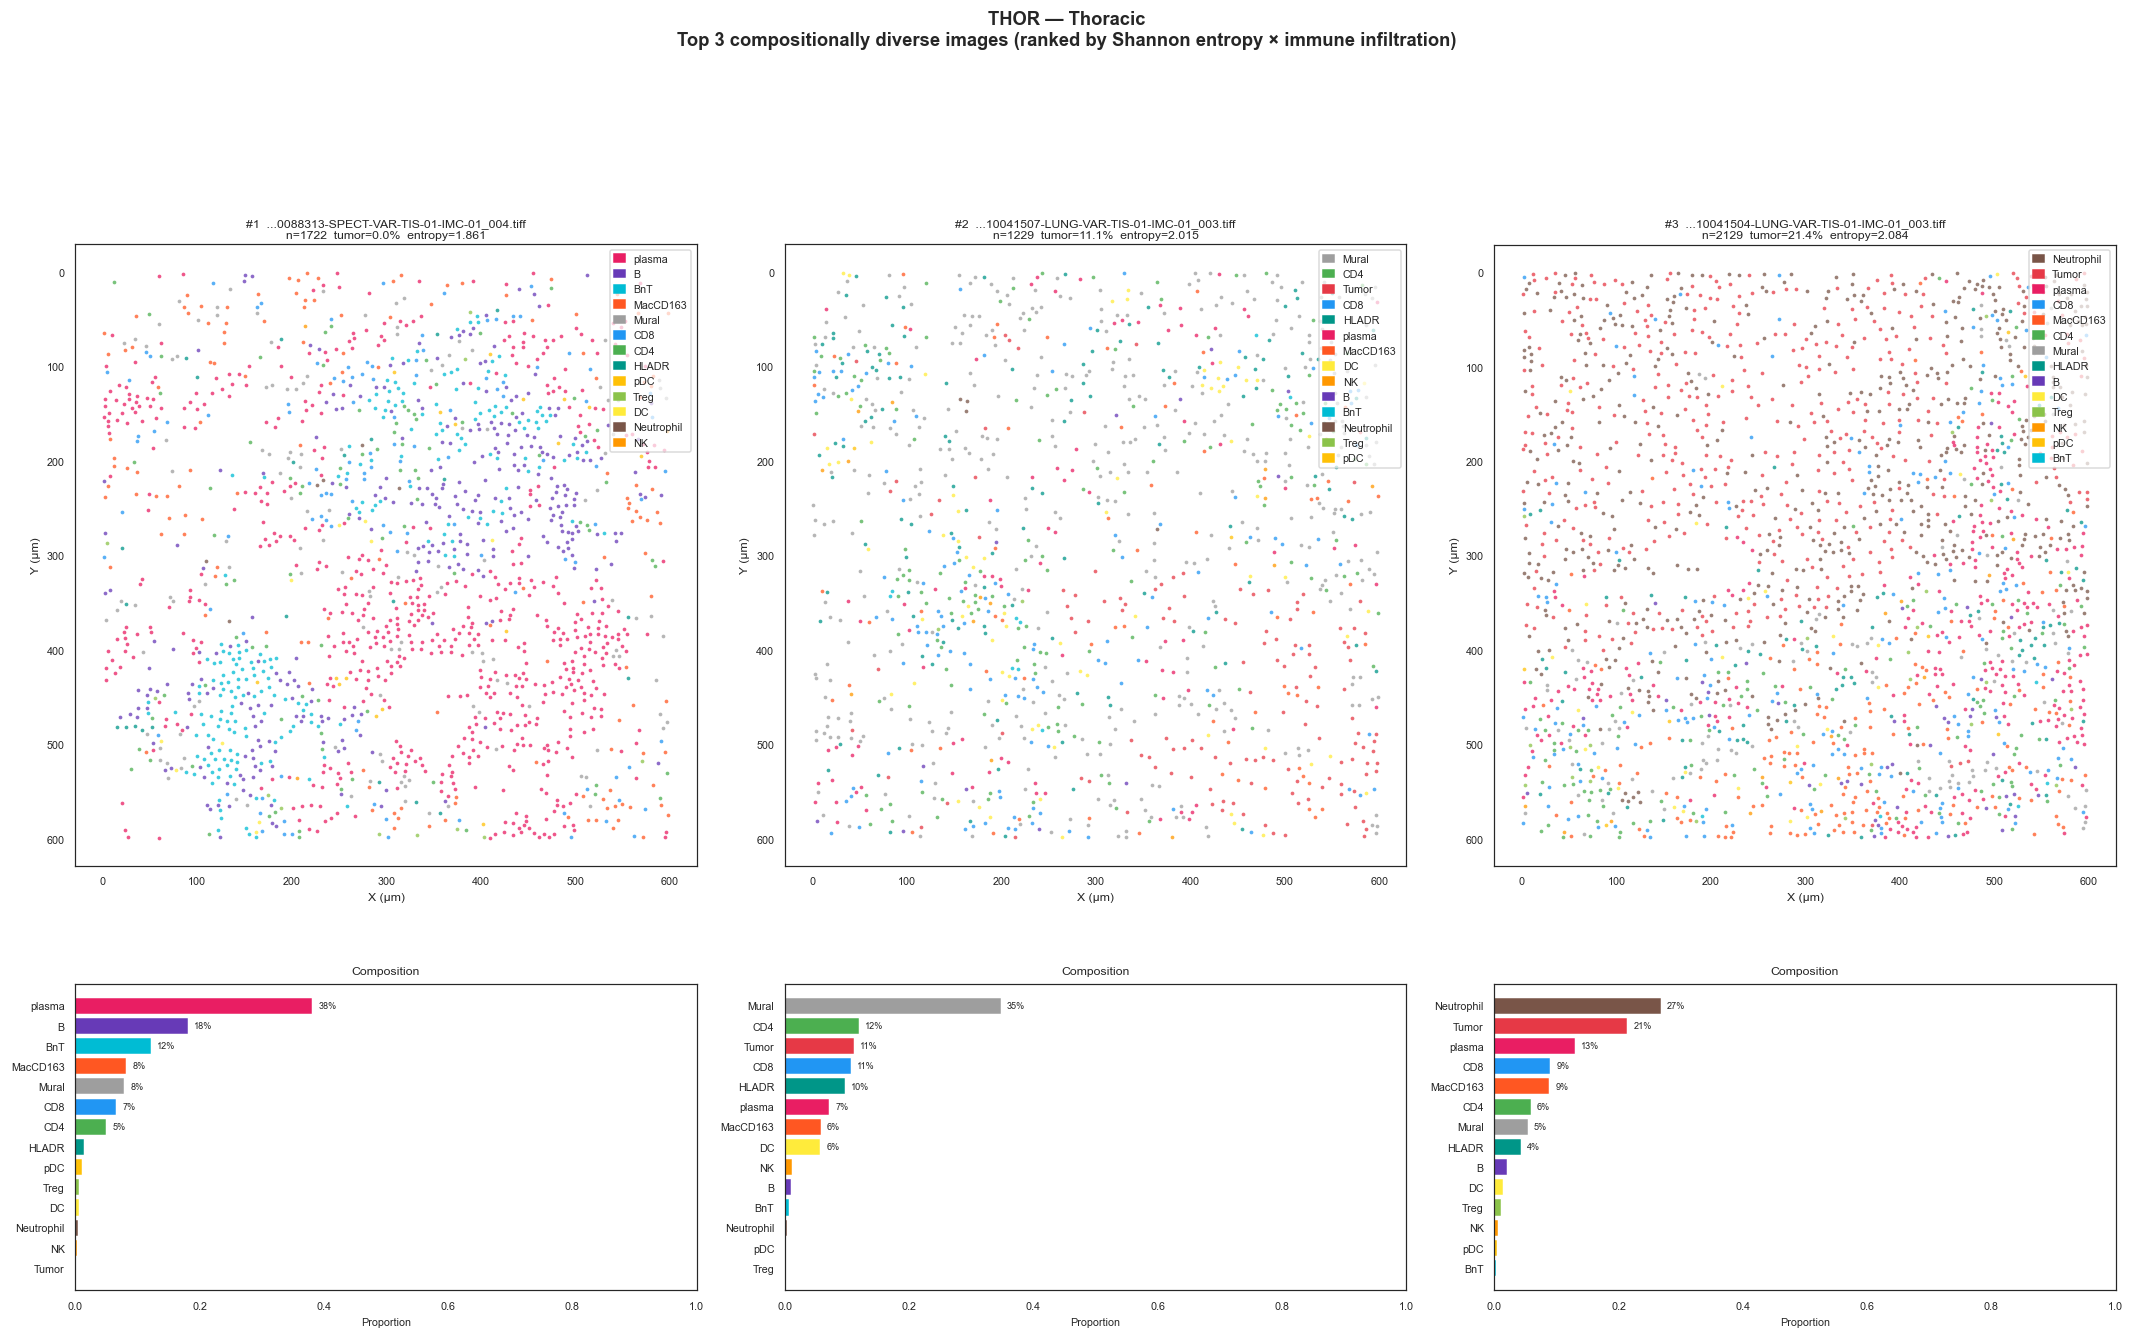

In [13]:
IND_LABELS = {
    'BREAS': 'BREAS — Breast cancer',
    'GI'   : 'GI — Gastrointestinal',
    'GU'   : 'GU — Genitourinary',
    'HN'   : 'HN — Head & Neck',
    'THOR' : 'THOR — Thoracic',
}

for ind, entries in diverse_samples.items():
    n = len(entries)  # 3
    # Layout: n columns × 2 rows (spatial on top, composition below)
    fig, axes = plt.subplots(
        2, n,
        figsize=(6.5 * n, 12),
        gridspec_kw={'height_ratios': [3, 1]},
    )

    for col, entry in enumerate(entries):
        img = entry['image']
        adata_img = adata[adata.obs['image'] == img]
        short = ('...' + img[-40:]) if len(img) > 43 else img

        title = (
            f"#{entry['rank']}  {short}\n"
            f"n={entry['n_cells']}  tumor={entry['tumor_prop']:.1%}  "
            f"entropy={entry['shannon_entropy']:.3f}"
        )

        # Spatial scatter
        plot_spatial_image(adata_img, axes[0, col], title=title, show_legend=True)

        # Composition bar
        plot_composition_bar(entry, axes[1, col])

    fig.suptitle(
        f'{IND_LABELS[ind]}\nTop 3 compositionally diverse images '
        f'(ranked by Shannon entropy × immune infiltration)',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()
    print()

---
## Part 5: Cross-Indication Overview — Best Sample per Cancer Type

The single #1-ranked image from each indication on one figure — a quick visual comparison of immune microenvironment architecture across cancer types.

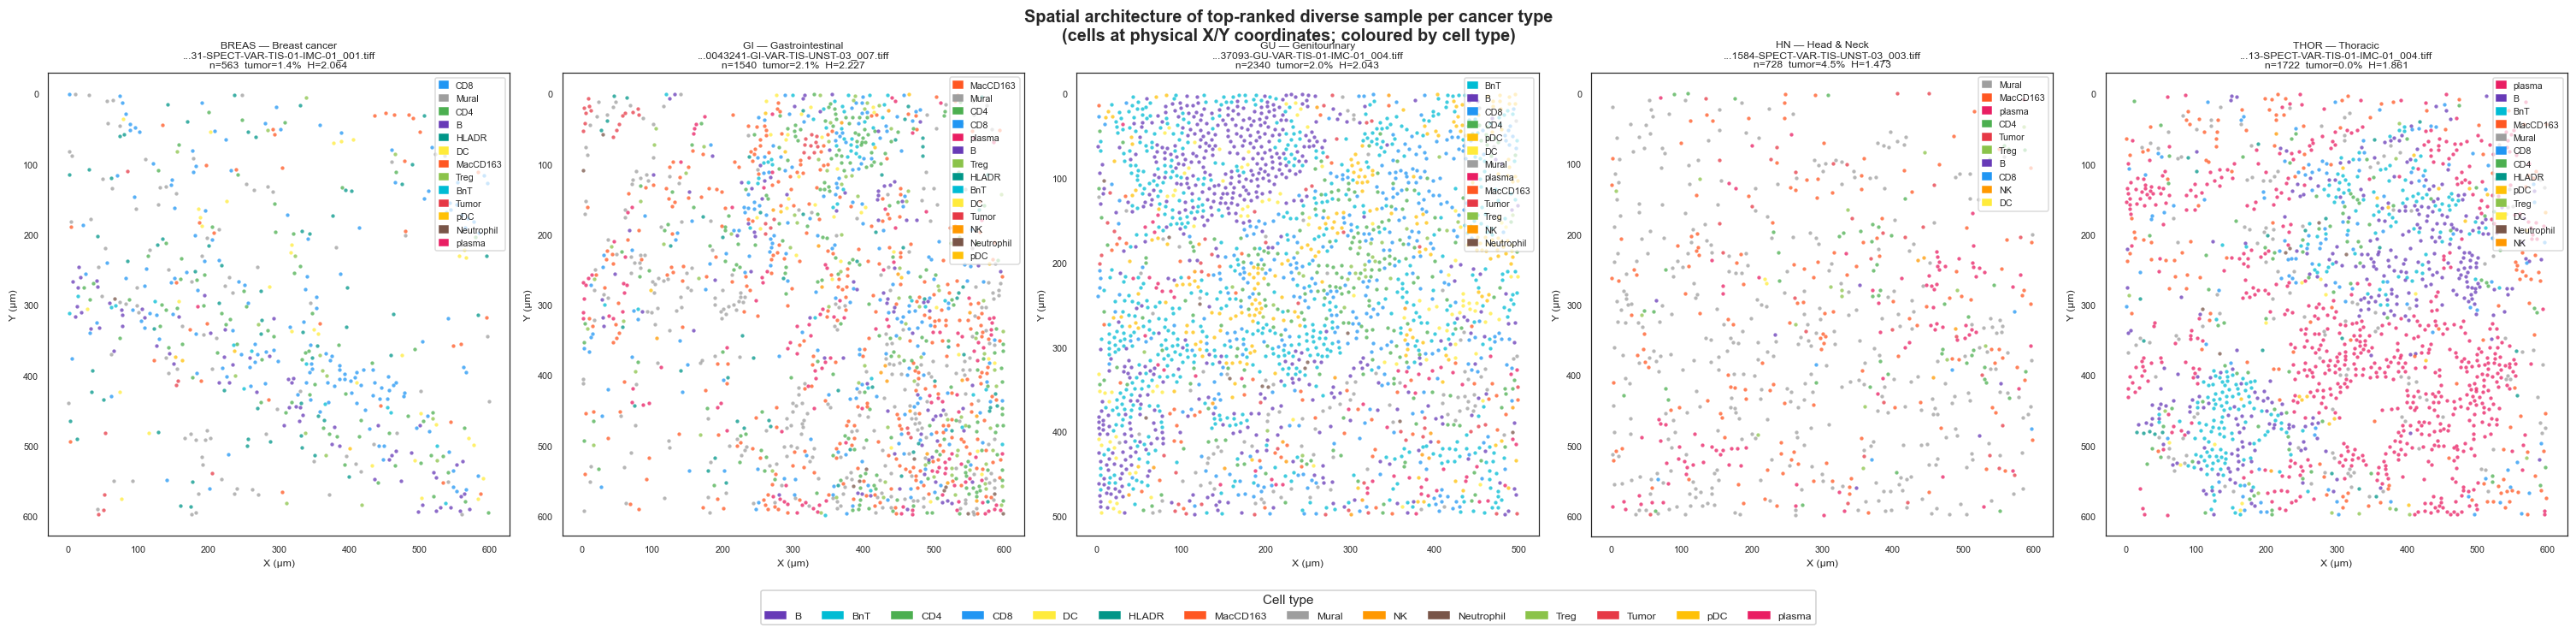

In [14]:
indications = list(diverse_samples.keys())   # BREAS, GI, GU, HN, THOR
n_ind = len(indications)

fig, axes = plt.subplots(1, n_ind, figsize=(5.5 * n_ind, 6))

for ax, ind in zip(axes, indications):
    entry = diverse_samples[ind][0]   # rank #1
    img = entry['image']
    adata_img = adata[adata.obs['image'] == img]
    short = ('...' + img[-35:]) if len(img) > 38 else img

    title = (
        f"{IND_LABELS[ind]}\n"
        f"{short}\n"
        f"n={entry['n_cells']}  tumor={entry['tumor_prop']:.1%}  "
        f"H={entry['shannon_entropy']:.3f}"
    )
    plot_spatial_image(adata_img, ax, title=title, show_legend=True, point_size=8)

# Shared legend: all cell types present across these 5 images
cts_shown = set()
for ind in indications:
    img = diverse_samples[ind][0]['image']
    cts_shown |= set(adata.obs.loc[adata.obs['image'] == img, 'celltypes'].unique())

handles = [
    mpatches.Patch(color=CT_PALETTE[ct], label=ct)
    for ct in sorted(cts_shown)
]
fig.legend(
    handles=handles, title='Cell type', fontsize=8,
    loc='lower center', ncol=len(cts_shown),
    bbox_to_anchor=(0.5, -0.12), framealpha=0.9
)

fig.suptitle(
    'Spatial architecture of top-ranked diverse sample per cancer type\n'
    '(cells at physical X/Y coordinates; coloured by cell type)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Part 6: Zoom-In on Tumour–Immune Interface

For the BREAS #1 sample (the most immune-infiltrated, only 1.4% tumor), we zoom into a spatial sub-region to highlight the fine-scale mixing of immune cell types.

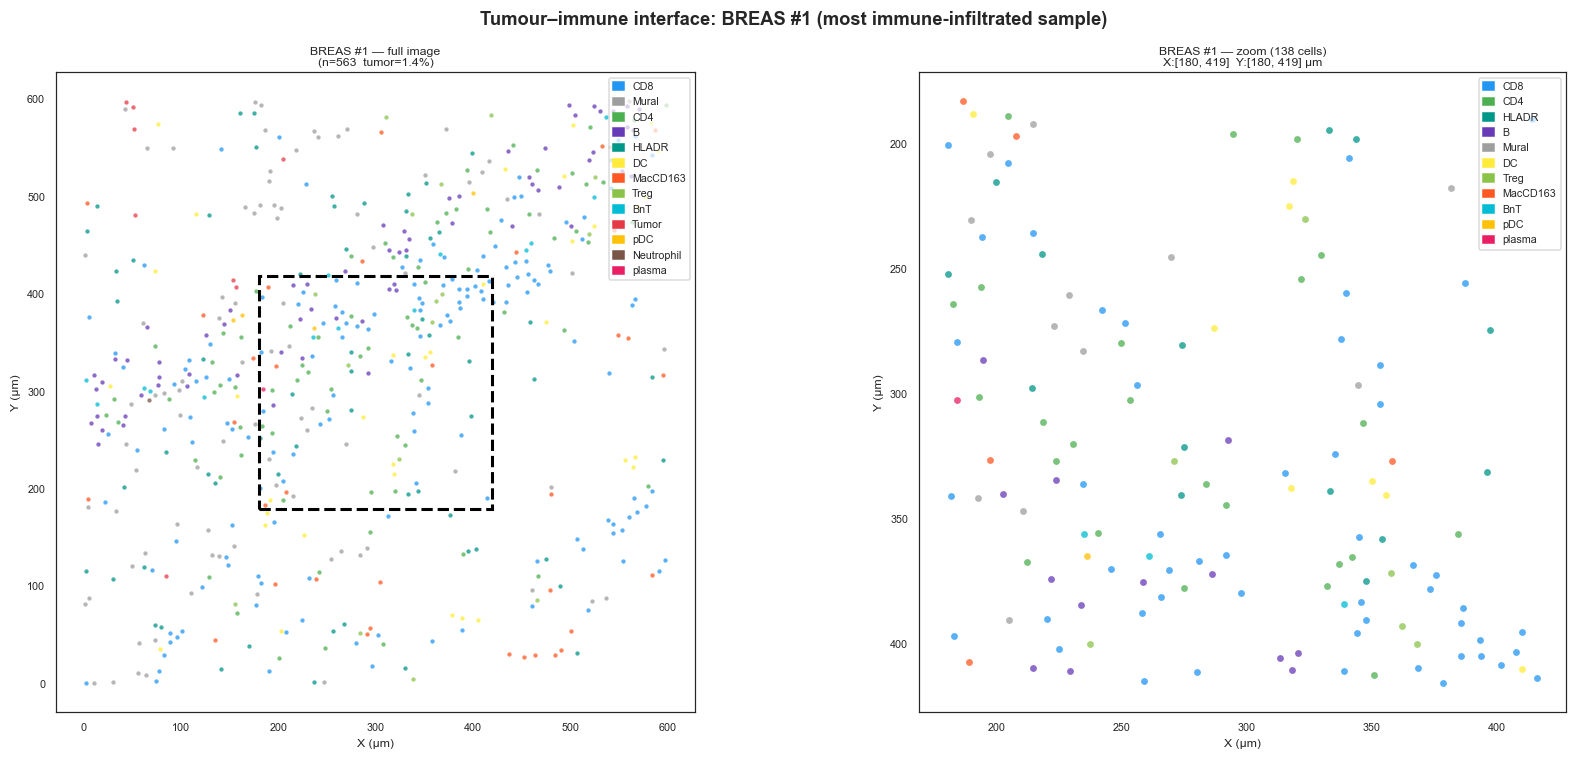

Zoom region: 138 cells
celltypes
CD8           51
CD4           24
HLADR         14
B             13
Mural         12
DC             8
Treg           6
MacCD163       5
BnT            3
pDC            1
plasma         1
NK             0
Neutrophil     0
Tumor          0


In [15]:
# Pick BREAS #1 — richest immune infiltrate
entry_breas1 = diverse_samples['BREAS'][0]
img_breas1   = entry_breas1['image']
obs_breas1   = adata.obs[adata.obs['image'] == img_breas1]

x_min, x_max = obs_breas1['Pos_X'].min(), obs_breas1['Pos_X'].max()
y_min, y_max = obs_breas1['Pos_Y'].min(), obs_breas1['Pos_Y'].max()
x_mid = (x_min + x_max) / 2
y_mid = (y_min + y_max) / 2

# Use middle 40% of the image as zoom region
x_range = x_max - x_min
y_range = y_max - y_min
zoom_x1, zoom_x2 = x_mid - 0.2 * x_range, x_mid + 0.2 * x_range
zoom_y1, zoom_y2 = y_mid - 0.2 * y_range, y_mid + 0.2 * y_range

obs_zoom = obs_breas1[
    (obs_breas1['Pos_X'] >= zoom_x1) & (obs_breas1['Pos_X'] <= zoom_x2) &
    (obs_breas1['Pos_Y'] >= zoom_y1) & (obs_breas1['Pos_Y'] <= zoom_y2)
]
adata_zoom = adata[obs_zoom.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full image
adata_breas1 = adata[adata.obs['image'] == img_breas1]
plot_spatial_image(
    adata_breas1, axes[0],
    title=f'BREAS #1 — full image\n(n={entry_breas1["n_cells"]}  tumor={entry_breas1["tumor_prop"]:.1%})',
    show_legend=True, point_size=8
)
# Draw zoom box
rect = plt.Rectangle(
    (zoom_x1, zoom_y1), zoom_x2 - zoom_x1, zoom_y2 - zoom_y1,
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
axes[0].add_patch(rect)
axes[0].invert_yaxis()  # re-invert after patch

# Zoomed region
plot_spatial_image(
    adata_zoom, axes[1],
    title=f'BREAS #1 — zoom ({len(obs_zoom)} cells)\nX:[{zoom_x1:.0f}, {zoom_x2:.0f}]  Y:[{zoom_y1:.0f}, {zoom_y2:.0f}] µm',
    show_legend=True, point_size=20
)

plt.suptitle('Tumour–immune interface: BREAS #1 (most immune-infiltrated sample)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Zoom region: {len(obs_zoom)} cells')
print(obs_zoom['celltypes'].value_counts().to_string())

---
## Part 7: Cell-Type Density Maps (KDE)

KDE contours overlay biology onto the scatter — useful for spotting spatial clustering or exclusion of specific cell types.

GI #1 — top 3 cell types: ['MacCD163', 'Mural', 'CD4']


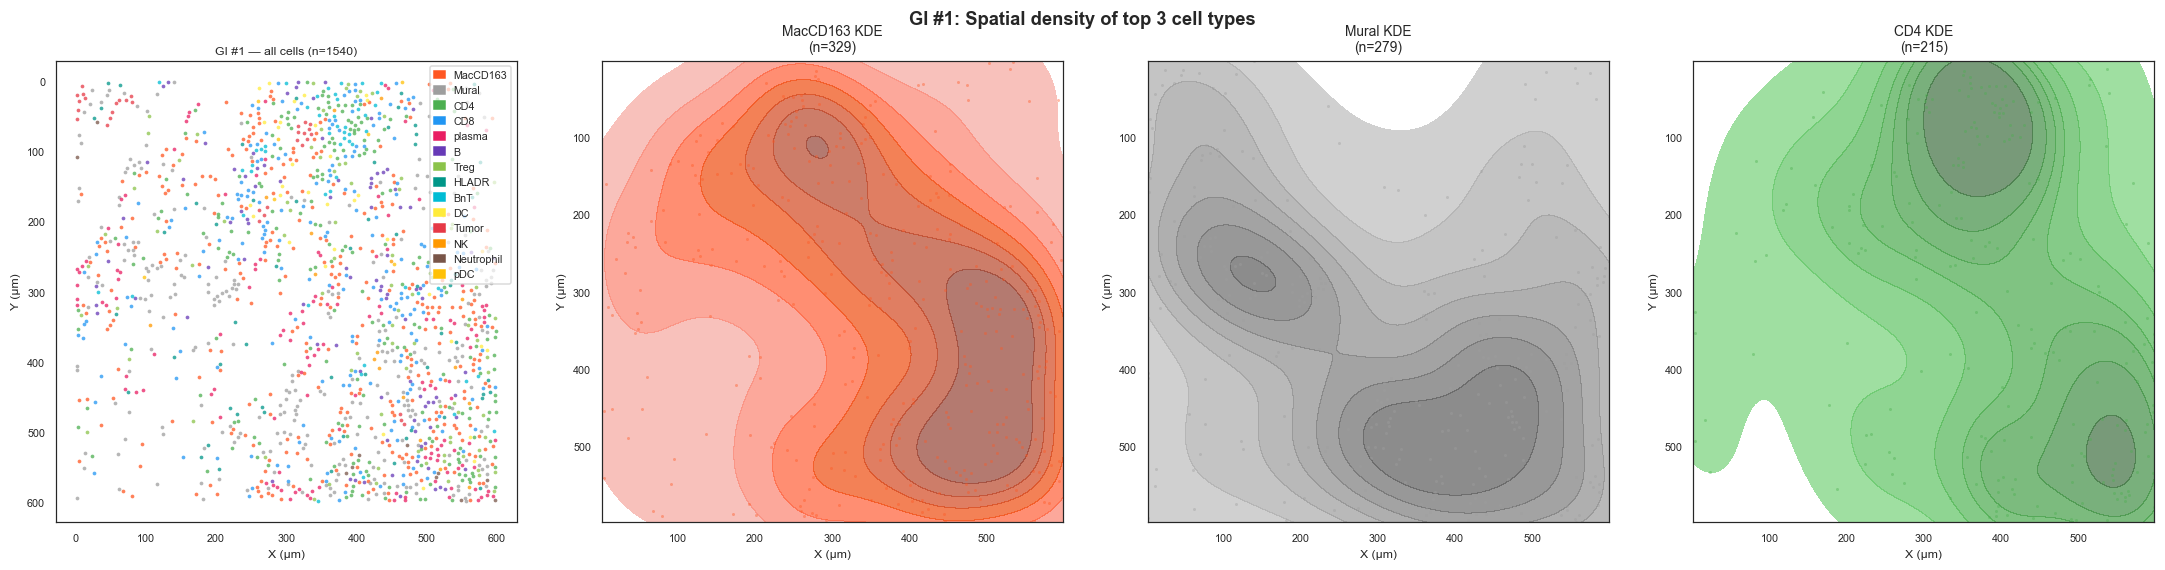

In [16]:
# Show KDE for 3 cell types in the GI #1 sample (rich macrophage + T cell mix)
entry_gi1 = diverse_samples['GI'][0]
img_gi1   = entry_gi1['image']
obs_gi1   = adata.obs[adata.obs['image'] == img_gi1]

# Pick the 3 most abundant cell types in this image
top3_ct = obs_gi1['celltypes'].value_counts().head(3).index.tolist()
print(f'GI #1 — top 3 cell types: {top3_ct}')

fig, axes = plt.subplots(1, len(top3_ct) + 1, figsize=(5 * (len(top3_ct) + 1), 5))

# Full spatial overview
adata_gi1 = adata[adata.obs['image'] == img_gi1]
plot_spatial_image(adata_gi1, axes[0],
                   title=f'GI #1 — all cells (n={entry_gi1["n_cells"]})',
                   show_legend=True, point_size=6)

# KDE per top cell type
for ax, ct in zip(axes[1:], top3_ct):
    obs_ct = obs_gi1[obs_gi1['celltypes'] == ct]
    if len(obs_ct) >= 5:
        sns.kdeplot(
            x=obs_ct['Pos_X'], y=obs_ct['Pos_Y'],
            ax=ax, fill=True, alpha=0.7,
            color=CT_PALETTE.get(ct, 'grey'),
            levels=8, thresh=0.05
        )
        ax.scatter(
            obs_ct['Pos_X'], obs_ct['Pos_Y'],
            c=CT_PALETTE.get(ct, 'grey'), s=4, alpha=0.4,
            linewidths=0, rasterized=True
        )
    ax.set_xlim(obs_gi1['Pos_X'].min(), obs_gi1['Pos_X'].max())
    ax.set_ylim(obs_gi1['Pos_Y'].min(), obs_gi1['Pos_Y'].max())
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(f'{ct} KDE\n(n={len(obs_ct)})', fontsize=9)
    ax.set_xlabel('X (µm)', fontsize=8)
    ax.set_ylabel('Y (µm)', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('GI #1: Spatial density of top 3 cell types', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

| Section | Key take-away |
|---------|---------------|
| Part 4 | 15 curated diverse images visualised — each cancer type shows distinct immune microenvironment architecture |
| Part 5 | Side-by-side comparison shows BREAS/GI/GU have richer T-cell infiltration than HN |
| Part 6 | Zoom-in tool reveals fine-scale immune cell mixing, not visible at full-image scale |
| Part 7 | KDE density maps quantify spatial clustering of specific cell types |

**Next:** Tutorial 3 (Squidpy) will formalise spatial relationships using neighbourhood graphs, co-occurrence scores, and Moran's I.

---